### This notebook compute "P11. Slope of the glacier mass" indicator for the 27 basins of IKI Project

Spanish: Pendiente de la masa glaciar

**Created:** 6/23/2025 by Jorge Mayo (jmayo@rti.org)  

**Inputs:**   MAPA_NACIONAL_DE_ECOSISTEMAS_2012-2018 (MINAM), INAIGEM inventario de glaciares 2020 https://geocatmin.ingemmet.gob.pe/geocatmin/ 
 
**Assumptions:** Instead of finding the 'mode' slope as noted in the guide, we found the average slope of each glaciar. Then, they were associated scores and the median score was assigned for each COMID. COMIDs without a glacier are assigned NaN so the indicator is not included in the calculation. 

**N/A Handling:** NaN values in slope rasters are ignored when calculating mean slope. NaN set to 0 for slope classes.  
 
**Notes:**  Preprocessed the DEM in GIS to find the slope. We will need to make changes in this script if we get a future glaciers shapefile

General Methodology:  
Slope raster (DEM) and glacier polygons
1. For each glacier geometry, clip the slope raster data  and calculate the mean slope.  
2. Classify the slopes: Default is 0 and gets overwritten with 1 for slopes > 40, 0.75 for slopes from (20,40], 0.5 for slopes from (10,20]; and 0.25 for slopes < 10.  
3. Groups glacial slope categories by COMID and calculates the median value per COMID.  


In [1]:
import pandas as pd
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
from rasterstats import zonal_stats
import rasterio
from rasterio.mask import mask
import numpy as np
from scipy.stats import mode
import yaml
from pathlib import Path

In [2]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [3]:
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"
glaciares = master_path / "Indicadores" / "Datos_INAIGEM" / "Glaciares_2020_COMID_v2.shp"
Peru_slope = master_path / "Indicadores" / "Otros_GIS" / "peru_slope.tif"
Peru_dem = master_path / "Indicadores" / "Otros_GIS" / "peru_dem_clip.tif"

In [4]:
# set up indicator ID and get scenarios from database
IndID= 111 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
# Load the shapefiles
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
glaciares_gdf = gpd.read_file(glaciares).to_crs('EPSG:32718')

In [6]:
# fix coordinate reference systems (CRS) if they do not match

# Check the CRS of the slope raster
with rasterio.open(Peru_slope) as src:
    slope_crs = src.crs
    print("Slope Raster CRS:", slope_crs)

# Check the CRS of the glacier polygons
print("Glacier Polygons CRS:", glaciares_gdf.crs)

# Compare the two CRS
if glaciares_gdf.crs == slope_crs:
    print("CRS match: The slope raster and glacier polygons have the same CRS.")
else:
    print("CRS mismatch: The slope raster and glacier polygons have different CRS.")

# Reproject the glacier polygons to match the slope raster CRS
with rasterio.open(Peru_slope) as src:
    slope_crs = src.crs
    glaciares_gdf = glaciares_gdf.to_crs(slope_crs)

# Verify the reprojected CRS
print("Reprojected Glacier Polygons CRS:", glaciares_gdf.crs)

Slope Raster CRS: EPSG:4326
Glacier Polygons CRS: EPSG:32718
CRS mismatch: The slope raster and glacier polygons have different CRS.
Reprojected Glacier Polygons CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [7]:
#CALCULATE MEAN SLOPE FOR EACH GLACIER POLYGON
# Open the slope raster
with rasterio.open(Peru_slope) as src:
    affine = src.transform
    crs = src.crs

# Create a list to store mean slope values for each glacier
glacier_slope_values = []

# Loop through each glacier polygon
for geom in glaciares_gdf.geometry:
    with rasterio.open(Peru_slope) as src:
        # Clip the slope raster to the glacier polygon
        out_image, out_transform = mask(src, [geom], crop=True)
        slope_clipped = out_image[0]  # Extract the slope data

        # Ignore nodata values
        slope_clipped = np.where(slope_clipped == src.nodata, np.nan, slope_clipped)

        # Calculate the mean slope for the glacier polygon
        mean_slope = np.nanmean(slope_clipped)  # Ignore NaN values
        glacier_slope_values.append(mean_slope)

# Add the mean slope values to the GeoDataFrame
glaciares_gdf['mean_slope'] = glacier_slope_values

# Assign slope classes
glaciares_gdf['slope_value'] = 0
glaciares_gdf.loc[glaciares_gdf['mean_slope'] > 40, 'slope_value'] = 1
glaciares_gdf.loc[(glaciares_gdf['mean_slope'] <= 40) & (glaciares_gdf['mean_slope'] > 20), 'slope_value'] = 0.75
glaciares_gdf.loc[(glaciares_gdf['mean_slope'] <= 20) & (glaciares_gdf['mean_slope'] > 10), 'slope_value'] = 0.5
glaciares_gdf.loc[glaciares_gdf['mean_slope'] <= 10, 'slope_value'] = 0.25

C:\Users\sbakar\AppData\Local\Temp\ipykernel_78864\3041916808.py:21: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)  # Ignore NaN values
C:\Users\sbakar\AppData\Local\Temp\ipykernel_78864\3041916808.py:21: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)  # Ignore NaN values
C:\Users\sbakar\AppData\Local\Temp\ipykernel_78864\3041916808.py:21: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)  # Ignore NaN values
C:\Users\sbakar\AppData\Local\Temp\ipykernel_78864\3041916808.py:21: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)  # Ignore NaN values
C:\Users\sbakar\AppData\Local\Temp\ipykernel_78864\3041916808.py:21: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)  # Ignore NaN values
C:\Users\sbakar\AppData\Local\Temp\ipykernel_78864\3041916808.py:21: RuntimeWarning: Mean of empty slice
  mean_slope = np.nanmean(slope_clipped)  # Ignore NaN value

In [8]:
#FIND MEDIAN SLOPE VALUE PER COMID

# Aggregate slope values by COMID, choosing the median slope_value
final_df = glaciares_gdf.groupby('COMID', as_index=False).agg({'slope_value': 'median'})

# Merge with subbasins
subbasins_gdf = subbasins_gdf.merge(final_df, on='COMID', how='left')

# Keep NaN for COMIDs without glaciers (don't fill with 0)
# This ensures only COMIDs with glaciers have slope values

array([[<Axes: title={'center': 'mean_slope'}>]], dtype=object)

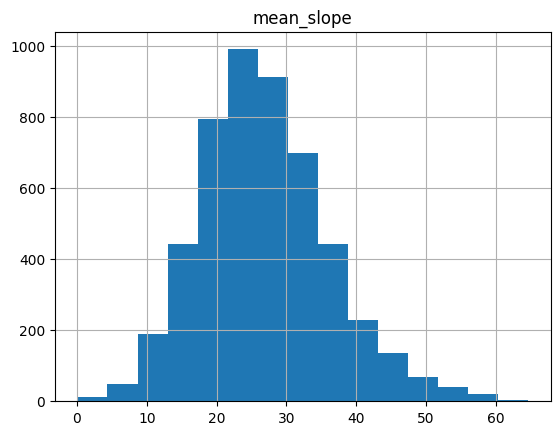

In [9]:
glaciares_gdf.hist(column='mean_slope', bins=15)

<Axes: >

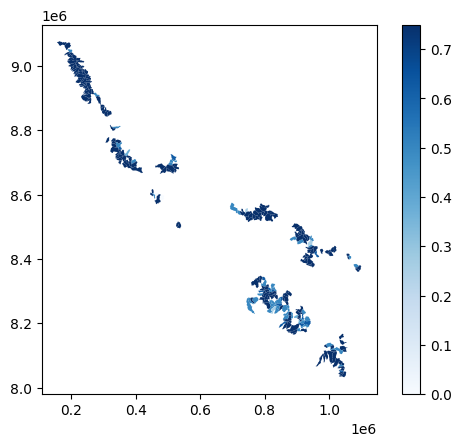

In [10]:
subbasins_gdf.plot(column='slope_value', cmap='Blues', legend=True)

<Axes: >

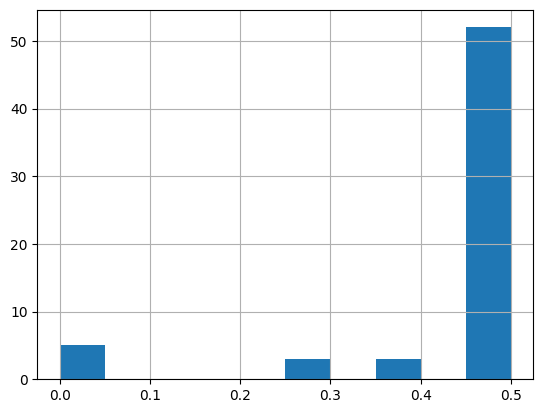

In [11]:
#histogram of values including zero 
subbasins_gdf['slope_value'].hist(bins=10, range=(0, .5))

In [12]:
insert_data= subbasins_gdf #COMID 
value_column= 'slope_value' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [13]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['slope_value']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 111  Min: 0, Max: 1

=== Values to be inserted ===
   index  slope_value
0    min         0.00
1    max         0.75
2  count       289.00
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [14]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()